In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
image_path="sampleImage.jpg"
img=np.array(Image.open(image_path).convert("L"))

In [8]:
print(f"Original image shape:{img.shape}")
print(f"Original image data type:{img.dtype}")

Original image shape:(601, 338)
Original image data type:uint8


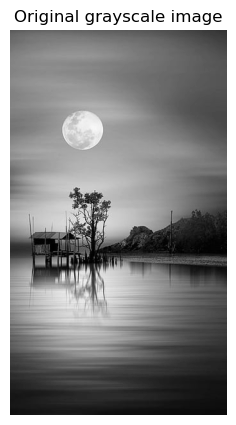

In [9]:
plt.figure(figsize=(6,5))
plt.imshow(img,cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")
plt.show()

In [10]:
def downsample(image,factor):
    """Keep only every 'factor' -th pixel in rows and columns."""
    return image[::factor,::factor]

(-0.5, 337.5, 600.5, -0.5)

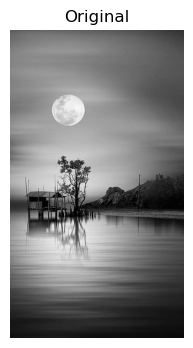

In [11]:
factors=[2,4,8]
plt.figure(figsize=(14,4))
plt.subplot(1,len(factors)+ 1,1)
plt.imshow(img,cmap="gray")
plt.title("Original")
plt.axis("off")

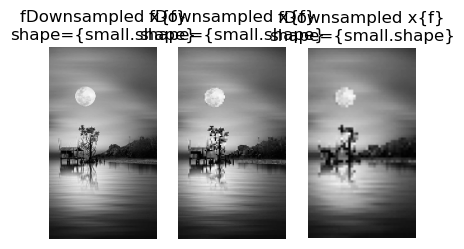

In [20]:
for i,f in enumerate(factors):
  small = downsample(img, f)
  plt.subplot(1,len(factors) + 1,i + 2)
  plt.imshow(small,cmap="gray")
  plt.title("fDownsampled x{f}\nshape={small.shape}")
  plt.axis("off")

In [24]:
small_img=downsample(img,8)
pil_small=Image.fromarray(small_img)
upsampled=pil_small.resize((img.shape[1],img.shape[0]),Image.Resampling.NEAREST)
upsampled=np.array(upsampled)

(-0.5, 337.5, 600.5, -0.5)

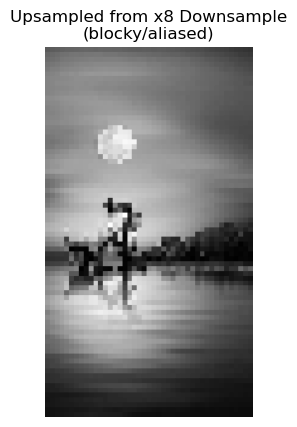

In [27]:
plt.subplot(1,2,2)
plt.imshow(upsampled,cmap="gray")
plt.title("Upsampled from x8 Downsample\n(blocky/aliased)")
plt.axis("off")

In [28]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [29]:
print("\nSampling:reducing resolution loses saptial detail permanently")
print("Upsampling only stretches existing pixels;it cannot recover lost details ")


Sampling:reducing resolution loses saptial detail permanently
Upsampling only stretches existing pixels;it cannot recover lost details 


In [30]:
def quantize(image,levels):
    """
    Reduce an 8 bit(0-255) grayscale image to a smaller number of gray levels.
    'levels' is how many distinct gray shades the output should have(e.g 4, 8, )"""
    
    step =256 // levels
    quantized=(image // step) * step
    return quantized.astype(np.uint8)

In [34]:
level_options=[256,16,8,4,2]
plt.figure(figsize=(16,4))

<Figure size 1600x400 with 0 Axes>

<Figure size 1600x400 with 0 Axes>

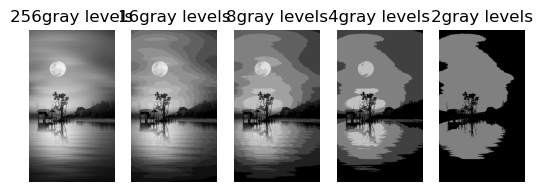

In [35]:
for i,levels in enumerate(level_options):
    q_img =quantize(img,levels)
    plt.subplot(1, len(level_options), i + 1)
    plt.imshow(q_img, cmap="gray", vmin=0,vmax=255)
    plt.title(f"{levels}gray levels")
    plt.axis("off")

In [36]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

5. show the "false contouring" effect clearly with very fex levels 

In [38]:
q2=quantize(img, 2)
q4=quantize(img, 4)

(-0.5, 337.5, 600.5, -0.5)

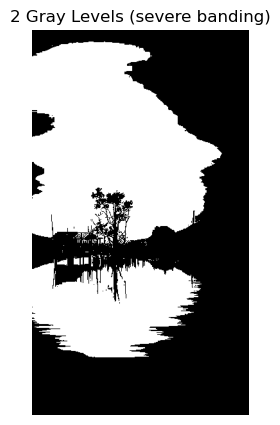

In [39]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(q2,cmap="gray")
plt.title("2 Gray Levels (severe banding)")
plt.axis("off")

(-0.5, 337.5, 600.5, -0.5)

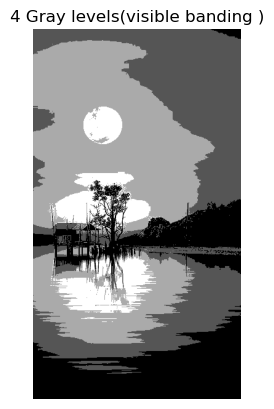

In [40]:
plt.subplot(1,2,2)
plt.imshow(q4, cmap="gray")
plt.title("4 Gray levels(visible banding )")
plt.axis("off")

In [42]:
print("\nQuantization: reducing gray levels causes   visible banding, called 'false countoring'.")
print("fewer levels =smaller file size but lower visual quality")


Quantization: reducing gray levels causes   visible banding, called 'false countoring'.
fewer levels =smaller file size but lower visual quality
